# `03_DBSCAN.ipynb`

## Topic 1 — Introduction to Density-Based Clustering

### 1. What is Density-Based Clustering?

Density-based clustering groups points based on **how densely packed the points are**.

The main idea is:

> **A cluster is a region where many data points are close together, separated from regions where there are few points.**

For example:

```text
        ● ● ●
      ● ● ● ●
        ● ● ●


                         ●


   ● ●
 ● ● ●
   ● ●
```

We can identify:

```text
Cluster 1        Cluster 2

  ● ● ●              ●
● ● ● ●
  ● ● ●


Cluster 3

 ● ●
● ● ●
 ● ●
```

The isolated point can potentially be considered **noise**.

---

# 2. Why Is This Different From K-Means?

K-Means tries to divide the data around **centroids**.

For example:

```text
        ● ● ●
      ● ● ●
          ×
        centroid
```

It essentially asks:

> Which centroid is this point closest to?

Because of this, K-Means works best when clusters are relatively compact and centroid-like.

---

## DBSCAN thinks differently

DBSCAN doesn't start with centroids.

Instead, it asks:

> **Where are enough points packed together?**

For example:

```text
● ● ● ●
 ● ● ●
  ● ●
```

This is a dense region.

So DBSCAN can identify it as a cluster without calculating a centroid.

---

# 3. What Does "Density" Mean?

Consider two regions.

### Region A

```text
● ● ●
● ● ●
● ● ●
```

Many points are close together.

So:

> High density.

### Region B

```text
●


          ●


                    ●
```

Points are far apart.

So:

> Low density.

DBSCAN uses this difference to identify clusters.

---

# 4. The Important Idea: Neighborhood

To determine whether a point belongs to a dense region, DBSCAN looks around that point.

Imagine a circle around a point:

```text
       ●
    ●  ●  ●
       ●
```

The circle represents the point's **neighborhood**.

DBSCAN asks:

> How many points are inside this neighborhood?

If there are enough points, the area is considered dense.

This neighborhood is controlled by a parameter called:

```text
eps
```

We'll study `eps` in detail later.

---

# 5. Density Is Local

This is important.

DBSCAN doesn't calculate one global density for the entire dataset.

It examines the neighborhood **around each point**.

For example:

```text
        ● ● ●
      ● ● ● ●
        ● ●
```

A point in the middle has many nearby neighbors.

Therefore, its local density is high.

But:

```text
                         ●
```

has very few nearby points.

Its local density is low.

---

# 6. Why Is This Useful?

Because many real datasets don't form nice circular clusters.

For example:

```text
       ● ● ●
     ●       ●
    ●         ●
     ●       ●
       ● ● ●
```

This is an irregularly shaped cluster.

K-Means can struggle because it is based on distances to centroids.

DBSCAN can identify this kind of structure because it follows **dense connected regions**.

---

# 7. DBSCAN Can Also Identify Noise

Consider:

```text
       ● ● ●
     ● ● ● ●
       ● ● ●


                         ●
```

The dense region can become a cluster.

The isolated point may be identified as **noise**.

This is a major advantage.

K-Means:

> Every point must belong to some cluster.

DBSCAN:

> Some points can be classified as noise.

---

# 8. Three Fundamental Concepts

DBSCAN eventually classifies points into three categories:

### Core point

A point in a sufficiently dense region.

### Border point

A point close to a core point, but not dense enough itself.

### Noise point

A point that doesn't belong to any dense region.

We'll study these **in detail in the next topic**, including a numerical example.

---

# 9. The Two Parameters

DBSCAN mainly depends on:

### `eps`

How far we look around a point.

### `min_samples`

How many points are needed in that neighborhood to consider it dense.

So the basic idea is:

$$\text{Density decision}=\text{Neighborhood size determined by }eps+\text{minimum points determined by }min_samples$$

For example:

```text
eps = 1.5
min_samples = 5
```

means roughly:

> Look within a radius of $1.5$ and require at least $5$ samples in that neighborhood.

We'll calculate this manually later.

---

# 10. What DBSCAN Does Not Need

Unlike K-Means, DBSCAN does **not require you to specify the number of clusters**.

K-Means:

```python
KMeans(n_clusters=3)
```

You explicitly provide:

$$K=3$$

DBSCAN:

```python
DBSCAN(eps=..., min_samples=...)
```

You don't say:

```text
number of clusters = 3
```

The number of clusters emerges from the density structure.

---

# 11. Main Intuition

Keep this picture in your mind:

```text
Dense region
      ↓
   Cluster

Sparse region
      ↓
   Noise
```

And the fundamental question DBSCAN asks is:

> **"Does this point have enough nearby points to be part of a dense region?"**

From there, DBSCAN expands the cluster through connected dense regions.

---

## Topic Progress

```text
03_DBSCAN.ipynb

✓ 1. Introduction to Density-Based Clustering
→ 2. Core, Border & Noise Points
→ 3. DBSCAN Algorithm
→ 4. eps & min_samples
→ 5. Parameter Selection (k-distance plot)
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

## Topic 2 — Core, Border & Noise Points

These are the **three types of points in DBSCAN**.

The classification depends on the number of points within a radius of `eps`.

---

# 1. Let's Use a Small Example

Consider these 1D points:

```text
A = 1
B = 2
C = 3
D = 8
E = 9
F = 20
```

Visualized:

```text
1    2    3              8    9                         20
A    B    C              D    E                          F
●    ●    ●              ●    ●                          ●
```

We'll use:

```text
eps = 1.5
min_samples = 3
```

Remember:

* `eps = 1.5` → look within distance $1.5$
* `min_samples = 3` → need at least 3 samples in the neighborhood
* **The point itself counts** toward `min_samples`.

---

# 2. Point A

A is at:

$$A=1$$

Find points within `eps = 1.5`.

Distance to B:

$$d(A,B)=|1-2|=1$$

Distance to C:

$$d(A,C)=|1-3|=2$$

Since:

$$1\leq1.5$$

B is a neighbor.

But:

$$2>1.5$$

C is not.

Don't forget A itself.

Therefore:

```text
Neighborhood(A) = {A, B}
```

Number of samples:

$$2$$

But:

$$2<3$$

Therefore:

**A is NOT a core point.**

---

# 3. Point B

B is:

$$B=2$$

Distance to A:

$$d(B,A)=|2-1|=1$$

Distance to C:

$$d(B,C)=|2-3|=1$$

Both are within `eps`.

Including B itself:

```text
Neighborhood(B) = {A, B, C}
```

Number of samples:

$$3$$

And:

$$3\geq3$$

Therefore:

**B is a Core Point.**

---

# 4. Point C

C is:

$$C=3$$

Distance to B:

$$d(C,B)=|3-2|=1$$

Distance to A:

$$d(C,A)=|3-1|=2$$

Therefore:

```text
Neighborhood(C) = {B, C}
```

Number of samples:

$$2$$

Since:

$$2<3$$

C is **not a core point**.

But C is within `eps` of B:

$$d(C,B)=1\leq1.5$$

and B is a core point.

Therefore C becomes a **Border Point**.

---

# 5. So What Do We Have?

For the first three points:

```text
        Core
         ↓
A     B     C
●     ●     ●
      ↑     ↑
    Core   Border
```

Specifically:

```text
A → not core yet
B → Core
C → Border
```

But why isn't A also called Border?

Because A is also within `eps` of the core point B:

$$d(A,B)=1\leq1.5$$

Therefore **A is also a Border Point**.

So:

```text
A → Border
B → Core
C → Border
```

---

# 6. Point D

D is:

$$D=8$$

Its nearby point is E:

$$d(D,E)=|8-9|=1$$

Therefore:

```text
Neighborhood(D) = {D, E}
```

Number of samples:

$$2$$

Since:

$$2<3$$

D is not core.

Now ask:

> Is D within `eps` of a core point?

The only nearby point is E, and E is also not core.

Therefore D is **Noise**.

---

# 7. Point E

Similarly:

```text
Neighborhood(E) = {D,E}
```

Number of samples:

$$2<3$$

E isn't core.

And E isn't within `eps` of any core point.

Therefore:

**E = Noise**

---

# 8. Point F

F is at:

$$F=20$$

There are no other points within $1.5$.

Therefore:

```text
Neighborhood(F) = {F}
```

Number of samples:

$$1<3$$

F isn't core.

And there is no nearby core point.

Therefore:

**F = Noise**

---

# 9. Final Classification

Our result is:

| Point | Neighborhood | Count | Classification |
| ----- | ------------ | ----: | -------------- |
| A     | `{A,B}`      |     2 | Border         |
| B     | `{A,B,C}`    |     3 | **Core**       |
| C     | `{B,C}`      |     2 | Border         |
| D     | `{D,E}`      |     2 | Noise          |
| E     | `{D,E}`      |     2 | Noise          |
| F     | `{F}`        |     1 | Noise          |

So visually:

```text
Cluster 1

Border     Core     Border
  A         B         C
  ●         ●         ●


Noise      Noise                    Noise
  D         E                         F
  ●         ●                         ●
```

---

# 10. The Exact Rules

This is what you should memorize.

### Core Point

A point is **Core** if:

$$|N_{\epsilon}(p)|\geq\text{min_samples}$$

where $N_{\epsilon}(p)$ is the set of points within `eps` of point $p$, including $p$ itself under sklearn's convention.

---

### Border Point

A point is **Border** if:

1. It does not have enough neighbors to be a core point.
2. It is within `eps` of a core point.

In other words:

```text
Not Core
+
Near Core
=
Border
```

---

### Noise

A point is **Noise** if:

1. It isn't a core point.
2. It isn't within `eps` of any core point.

So:

```text
Not Core
+
Not connected to Core
=
Noise
```

---

# 11. The Most Important Difference

Look at A and D:

```text
A → has only 2 points in its neighborhood
D → has only 2 points in its neighborhood
```

Both are **not core**.

But:

```text
A → near B, which IS core
D → near E, which is NOT core
```

Therefore:

```text
A → Border
D → Noise
```

This is the key reason we need all three categories.

---

# 12. Mental Model

Think of the three types like this:

```text
CORE
↓
Dense enough
↓
Can create and expand a cluster


BORDER
↓
Not dense enough itself
↓
But attached to a core point


NOISE
↓
Not dense enough
↓
Not attached to any core point
```

One subtle but important point: **a border point does not expand the cluster**. Only core points can cause DBSCAN to keep exploring and expanding the cluster.

---

## Topic Progress

```text
03_DBSCAN.ipynb

✓ 1. Introduction to Density-Based Clustering
✓ 2. Core, Border & Noise Points
→ 3. DBSCAN Algorithm
→ 4. eps & min_samples
→ 5. Parameter Selection (k-distance plot)
→ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```

## Topic 3 — DBSCAN Algorithm

Now let's see **how DBSCAN actually uses Core, Border, and Noise points to build clusters**.

### 1. Start with all points unvisited

Suppose:

```text
A  B  C  D  E  F
●  ●  ●  ●  ●  ●
```

DBSCAN goes through the points one by one.

For our example:

```text
eps = 1.5
min_samples = 3
```

---

### 2. Pick the first unvisited point

Start with A.

We calculate its `eps` neighborhood:

```text
Neighborhood(A) = {A, B}
```

So:

$$|N_{\epsilon}(A)|=2$$

Since:

$$2<3$$

A is **not a Core point**.

At this stage, DBSCAN doesn't have enough information to expand a cluster from A.

---

### 3. Move to B

Now B is examined.

Its neighborhood is:

```text
Neighborhood(B) = {A, B, C}
```

Therefore:

$$|N_{\epsilon}(B)|=3$$

Since:

$$3\geq3$$

B is a **Core point**.

So DBSCAN starts a new cluster:

```text
Cluster 0 = {B}
```

---

### 4. Expand the Cluster

Because B is a Core point, DBSCAN takes all of B's neighbors:

```text
A, B, C
```

and adds them to the cluster:

```text
Cluster 0 = {A, B, C}
```

Now DBSCAN checks:

> Can A or C expand this cluster further?

---

### 5. Check A

A has:

```text
Neighborhood(A) = {A, B}
```

Only 2 points:

$$2<3$$

So A is **not Core**.

Therefore A cannot expand the cluster.

But A is already connected to the Core point B, so A remains a **Border point**.

---

### 6. Check C

Similarly:

```text
Neighborhood(C) = {B, C}
```

So:

$$2<3$$

C is not Core.

Therefore C also cannot expand the cluster.

It remains a Border point.

So:

```text
Cluster 0

A      B      C
●      ●      ●
       Core
```

---

# 7. Move to D

DBSCAN continues scanning the dataset.

D has:

```text
Neighborhood(D) = {D, E}
```

Therefore:

$$2<3$$

D isn't Core.

So DBSCAN doesn't start a cluster from D.

---

# 8. Move to E

E also has:

```text
Neighborhood(E) = {D, E}
```

Therefore:

$$2<3$$

E isn't Core either.

Since neither D nor E is connected to a Core point, they become **Noise**.

---

# 9. Move to F

F has no nearby points:

```text
Neighborhood(F) = {F}
```

Therefore:

$$1<3$$

F isn't Core.

There is also no nearby Core point.

So F becomes **Noise**.

---

# 10. Final Result

```text
Cluster 0:

A ─── B ─── C
    Core
```

and:

```text
Noise:

D     E                 F
●     ●                 ●
```

So:

```text
A → Border
B → Core
C → Border

D → Noise
E → Noise
F → Noise
```

---

# 11. The Important Part: Cluster Expansion

The most important concept in DBSCAN is **cluster expansion**.

Suppose we have:

```text
A → B → C → D → E
```

and B, C, and D are Core points.

If DBSCAN reaches B:

```text
B is Core
↓
Add B's neighbors
↓
Find C
↓
C is Core
↓
Add C's neighbors
↓
Find D
↓
D is Core
↓
Add D's neighbors
↓
...
```

So the cluster can **grow through a chain of Core points**.

This is called **density connectivity**.

---

# 12. Why Border Points Don't Expand

Suppose:

```text
A ─── B ─── C
    Core   Border
```

C is Border.

Even if C has some neighbors, if C doesn't satisfy:

$$|N_{\epsilon}(C)|\geq\text{min_samples}$$

then C cannot cause DBSCAN to search further.

So:

```text
Core → can expand
Border → cannot expand
Noise → doesn't belong to cluster
```

---

# 13. Complete DBSCAN Flow

The algorithm can be summarized as:

```text
Pick an unvisited point
        ↓
Find its eps-neighborhood
        ↓
Is it Core?
   ↙          ↘
 YES          NO
 ↓             ↓
Create       Mark as
cluster      noise temporarily
 ↓
Add neighbors
 ↓
For each neighbor:
        ↓
   Is it Core?
    ↙       ↘
   YES       NO
    ↓         ↓
Expand      Add as
cluster     Border
    ↓
Continue
 ↓
No more points to add
 ↓
Cluster finished
 ↓
Move to next unvisited point
```

---

# 14. The Key Difference From Hierarchical Clustering

Hierarchical clustering:

```text
Closest clusters
       ↓
Merge
       ↓
Merge
       ↓
Merge
```

DBSCAN:

```text
Core point
     ↓
Find neighbors
     ↓
Find more Core points
     ↓
Expand
     ↓
Continue through dense regions
```

So DBSCAN doesn't build a hierarchy.

It **grows clusters based on density connectivity**.

---

## The one sentence to remember

> **DBSCAN starts from a Core point and expands the cluster through neighboring Core points, while Border points are added to the cluster but do not expand it, and points not connected to any Core point become Noise.**


Let's do a **complete DBSCAN dry run** with actual points, and see exactly **which points become Core, Border, and Noise**, and how the clusters are formed.

## Example

We'll use these 2D points:

```text
A = (1, 1)
B = (1, 2)
C = (2, 1)
D = (2, 2)
E = (3, 2)

F = (8, 8)
G = (8, 9)
H = (9, 8)
I = (9, 9)

J = (15, 15)
```

Visual idea:

```text
Cluster 1                    Cluster 2

     B ●   E ●                  G ● I ●
       ● D                        ●
     A ● C ●                    F ● H ●


                                      J ●
```

We'll choose:

```text
eps = 1.5
min_samples = 4
```

Remember: **the point itself counts** toward `min_samples`.

---

# Step 1 — Start with A

A:

$$A=(1,1)$$

We find all points within distance $1.5$.

Distance to B:

$$d(A,B)=\sqrt{(1-1)^2+(1-2)^2}=1$$

Distance to C:

$$d(A,C)=\sqrt{(1-2)^2+(1-1)^2}=1$$

Distance to D:

$$d(A,D)=\sqrt{(1-2)^2+(1-2)^2}=\sqrt{2}\approx1.414$$

Distance to E:

$$d(A,E)=\sqrt{(1-3)^2+(1-2)^2}=\sqrt{5}\approx2.236$$

So E is outside `eps`.

Therefore:

```text
Neighborhood(A) = {A, B, C, D}
```

Count:

$$|N(A)|=4$$

And:

$$4\geq4$$

Therefore:

**A is a Core point.**

---

# Step 2 — Start Cluster 0

Because A is Core, DBSCAN creates:

```text
Cluster 0 = {A}
```

Then it adds A's neighbors:

```text
Cluster 0 = {A, B, C, D}
```

But we're **not finished**.

Now DBSCAN checks B, C and D to see whether they are also Core points.

This is where cluster expansion happens.

---

# Step 3 — Check B

B:

$$B=(1,2)$$

Nearby points:

* A → distance $1$
* C → distance $\sqrt{2}\approx1.414$
* D → distance $1$
* E → distance $2$

So:

```text
Neighborhood(B) = {A, B, C, D}
```

Count:

$$4$$

Therefore:

$$4\geq4$$

**B is Core.**

Because B is Core, DBSCAN checks B's neighbors for new points.

No new point is discovered here.

---

# Step 4 — Check C

C:

$$C=(2,1)$$

Nearby points:

* A → $1$
* B → $\sqrt{2}$
* D → $1$
* E → $\sqrt{2}$

Therefore:

```text
Neighborhood(C) = {A, B, C, D, E}
```

Count:

$$5$$

Since:

$$5\geq4$$

**C is Core.**

And now something important happens.

C has discovered:

```text
E
```

which wasn't previously in our cluster.

So E is added:

```text
Cluster 0 = {A, B, C, D, E}
```

---

# Step 5 — Check D

D:

$$D=(2,2)$$

Nearby:

```text
A → √2
B → 1
C → 1
E → 1
```

including itself:

```text
D
```

So:

```text
Neighborhood(D) = {A, B, C, D, E}
```

Count:

$$5$$

Therefore D is also **Core**.

No new points are discovered.

---

# Step 6 — Check E

E:

$$E=(3,2)$$

Nearby:

```text
C → 1
D → 1
```

and itself.

So:

```text
Neighborhood(E) = {C, D, E}
```

Count:

$$3$$

Since:

$$3<4$$

E is **NOT Core**.

But E is already connected to Core point C:

$$d(E,C)=1$$

Therefore:

**E is a Border point.**

It belongs to Cluster 0 but does not expand the cluster.

---

# Step 7 — First Cluster Is Finished

We now have:

```text
Cluster 0

A ● ─── ● B
│ ╲   ╱ │
│   ●   │
C ● ─── ● D ─── E ●
```

Classification:

| Point | Type   |
| ----- | ------ |
| A     | Core   |
| B     | Core   |
| C     | Core   |
| D     | Core   |
| E     | Border |

So:

```text
Cluster 0 = {A, B, C, D, E}
```

---

# Step 8 — Move to F

DBSCAN now continues scanning the dataset.

F:

$$F=(8,8)$$

Nearby points:

* G → $1$
* H → $1$
* I → $\sqrt{2}$

Including itself:

```text
Neighborhood(F) = {F,G,H,I}
```

Count:

$$4$$

Therefore:

**F is Core.**

Since F is a Core point, DBSCAN starts a **new cluster**:

```text
Cluster 1 = {F}
```

Then adds its neighbors:

```text
Cluster 1 = {F,G,H,I}
```

---

# Step 9 — Check G

G is:

$$G=(8,9)$$

Its neighborhood:

```text
{F, G, I}
```

Wait — let's calculate carefully.

Distance to H:

$$d(G,H)=\sqrt{(8-9)^2+(9-8)^2}=\sqrt{2}\approx1.414$$

So actually:

```text
Neighborhood(G) = {F,G,H,I}
```

Count:

$$4$$

Therefore G is **Core**.

---

# Step 10 — Check H

Similarly:

```text
Neighborhood(H) = {F,G,H,I}
```

Count:

$$4$$

So H is **Core**.

---

# Step 11 — Check I

I:

$$I=(9,9)$$

Its neighborhood:

```text
{F,G,H,I}
```

Count:

$$4$$

Therefore I is also **Core**.

So:

```text
Cluster 1 = {F,G,H,I}
```

---

# Step 12 — Move to J

J:

$$J=(15,15)$$

There are no points within $1.5$.

So:

```text
Neighborhood(J) = {J}
```

Count:

$$1<4$$

J is not Core.

And J is not within `eps` of any Core point.

Therefore:

**J is Noise.**

---

# Final Result

We have:

```text
Cluster 0                  Cluster 1

A ● B ●                    F ● G ●
  ● ● E ●                    ● ●
C   D                      H   I


                              J ●
                              Noise
```

### Cluster 0

$$C_0={A,B,C,D,E}$$

### Cluster 1

$$C_1={F,G,H,I}$$

### Noise

$$\text{Noise}={J}$$

---

# Final Point Classification

| Point | Type   | Cluster |
| ----- | ------ | ------- |
| A     | Core   | 0       |
| B     | Core   | 0       |
| C     | Core   | 0       |
| D     | Core   | 0       |
| E     | Border | 0       |
| F     | Core   | 1       |
| G     | Core   | 1       |
| H     | Core   | 1       |
| I     | Core   | 1       |
| J     | Noise  | None    |

---

## The important thing to notice

The number of **Core points** does NOT determine the number of clusters directly.

Here we have:

$$8\text{ Core points}$$

but only:

$$2\text{ clusters}$$

because the Core points form **two separate density-connected regions**.

The process is:

$$\text{Core point}\rightarrow\text{neighbors}\rightarrow\text{more Core points}\rightarrow\text{expand cluster}$$

When DBSCAN finds another **unvisited Core point that isn't density-connected to the first cluster**, it starts a **new cluster**.

That's the key mechanism behind DBSCAN.


## Topic 4 — `eps` and `min_samples`

These are the **two most important parameters in DBSCAN**.

```text
eps          → How far do we look?
min_samples → How many points do we need?
```

---

# 1. `eps`

`eps` defines the **radius of the neighborhood** around each point.

Suppose:

```python
eps = 2
```

Then for a point $P$, DBSCAN considers another point $Q$ a neighbor if:

$$d(P,Q)\leq2$$

For example, in 1D:

```text
P = 5
```

Then points like:

```text
3    4    5    6    7
●    ●    P    ●    ●
```

are within distance $2$.

But:

```text
2                         8
●                         ●
```

are outside.

---

# 2. `eps` Is a Radius, Not the Number of Neighbors

This is important.

If:

```python
eps = 2
```

it does **not** mean:

> Find 2 neighbors.

It means:

> Look within a distance of 2.

The number of points found inside that radius is then used to determine density.

---

# 3. `min_samples`

`min_samples` tells DBSCAN how many samples must exist in the `eps` neighborhood for a point to be Core.

For example:

```python
min_samples = 4
```

Then:

$$|N_{\epsilon}(P)|\geq4$$

means P is Core.

Remember, **P itself is included** in this count in Scikit-learn.

---

# 4. Let's Combine Them

Suppose:

```text
eps = 2
min_samples = 4
```

Consider:

```text
● ● ● P
```

If all 4 points are within distance 2 of P:

$$|N_{\epsilon}(P)|=4$$

Therefore:

$$4\geq4$$

P is **Core**.

---

Now suppose:

```text
● P ●
```

Only 3 points including P are within the radius:

$$|N_{\epsilon}(P)|=3$$

Then:

$$3<4$$

P is **not Core**.

It could still be a Border point if it's near another Core point.

---

# 5. What Happens If You Increase `eps`?

Suppose:

```text
eps = 1
```

The neighborhood is small:

```text
      ●
    ● P ●
      ●
```

Maybe only 3 points are found.

Now increase:

```text
eps = 3
```

The neighborhood becomes larger:

```text
          ●
      ● ● ● ●
    ● ● P ● ●
      ● ● ●
          ●
```

More points can fall inside the neighborhood.

Therefore, increasing `eps` generally makes it **easier for points to become Core**.

---

# 6. What If `eps` Is Too Small?

Suppose your points look like:

```text
● ● ● ● ●
```

but `eps` is extremely small.

Each point may see only itself:

```text
●       ●       ●       ●
```

Then:

$$|N_{\epsilon}(P)|<\text{min_samples}$$

for many points.

Result:

> Too many points become Noise.

So:

```text
eps too small
→ very small neighborhoods
→ few Core points
→ lots of Noise
```

---

# 7. What If `eps` Is Too Large?

Now imagine:

```text
Cluster A              Cluster B

● ● ●                  ● ● ●
● ● ●                  ● ● ●
```

If `eps` is very large, points from both groups may fall inside each other's neighborhoods.

Then DBSCAN can connect them:

```text
Cluster A ───────── Cluster B
             ↓
        one cluster
```

So:

```text
eps too large
→ neighborhoods become huge
→ separate clusters may get connected
→ fewer, larger clusters
```

---

# 8. What Happens When `min_samples` Changes?

Suppose:

```text
eps = 2
```

and a point has:

$$5$$

points in its neighborhood.

### If:

```python
min_samples = 4
```

then:

$$5\geq4$$

→ Core.

### If:

```python
min_samples = 6
```

then:

$$5<6$$

→ Not Core.

So increasing `min_samples` makes it **harder to become a Core point**.

---

# 9. Effect of `min_samples`

### Too small

```text
min_samples = 2
```

Almost every small group can become dense.

You may get:

* too many Core points
* too many clusters
* noise being absorbed into clusters

### Too large

```text
min_samples = 20
```

You need a very dense region to become Core.

You may get:

* fewer Core points
* smaller number of clusters
* lots of Noise

---

# 10. `eps` and `min_samples` Work Together

Think of them like this:

```text
eps
 ↓
How big is my search area?


min_samples
 ↓
How many points must I find there?
```

For example:

```text
eps = 1.5
min_samples = 5
```

means:

> Look within radius $1.5$. If there are at least 5 samples there, classify the point as Core.

---

# 11. A Useful Mental Picture

Imagine standing at point P with a circular flashlight.

```text
              ●
          ●       ●

       ●     P      ●

          ●       ●
              ●
```

`eps` controls the **size of your flashlight**.

```text
Small eps → 🔦 small area
Large eps → 🔦 large area
```

`min_samples` controls:

> **How many people need to be inside your flashlight for this area to be considered dense?**

So:

$$\text{Core}\iff |N_{\epsilon}(P)|\geq\text{min_samples}$$

---

# 12. Important Relationship

There is a trade-off:

| Parameter     | Increase it                           | Decrease it                 |
| ------------- | ------------------------------------- | --------------------------- |
| `eps`         | More neighbors, easier to become Core | Fewer neighbors, more Noise |
| `min_samples` | Harder to become Core, more Noise     | Easier to become Core       |

But don't memorize these as absolute rules for every possible dataset; the actual clustering also depends on the data distribution and scaling.

---

# 13. Why Scaling Matters

DBSCAN is distance-based.

Suppose your features are:

```text
Age     → 18–60
Income  → 20,000–200,000
```

The income feature can dominate the distance calculation.

So we often use:

```python
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
```

Then choose `eps` based on the **scaled data**, not the original units.

---

# 14. One Important Difference From K-Means

K-Means has:

```text
n_clusters
```

DBSCAN has:

```text
eps
min_samples
```

K-Means:

> You specify **how many clusters**.

DBSCAN:

> You specify **what density should count as a cluster**.

The number of clusters is then discovered automatically.

---

## The key formula

$$\text{Core point}\iff |N_{\epsilon}(P)|\geq\text{min_samples}$$

Remember:

**`eps` = neighborhood radius**

**`min_samples` = minimum samples needed inside that neighborhood**


## Topic 5 — Choosing `eps` Using the k-Distance Plot

Choosing `eps` is one of the most important parts of DBSCAN.

You usually **don't want to randomly guess**:

```python
eps = 0.5
```

Instead, we can use a **k-distance plot**.

---

# 1. What are we trying to find?

We want an `eps` value that separates:

```text
Dense points
```

from:

```text
Sparse/noise points
```

The k-distance plot helps us find this boundary.

---

# 2. First, Choose `k`

Usually we connect `k` to `min_samples`.

For example:

```python
min_samples = 4
```

Then we commonly look at the distance to the **4th nearest neighbor**.

So:

$$k=4$$

---

# 3. What Does "4th Nearest Neighbor" Mean?

Suppose we have point P:

```text
P ●
```

and its neighbors are at distances:

```text
id="k7x4cr"
1st nearest → 0.3
2nd nearest → 0.5
3rd nearest → 0.7
4th nearest → 1.2
5th nearest → 2.5
```

The **4-distance** for P is:

$$d_4(P)=1.2$$

We only care about the 4th nearest neighbor.

---

# 4. Do This for Every Point

Suppose we have 10 points.

For every point, calculate its 4th-nearest-neighbor distance:

```text
Point     4th-neighbor distance
A              0.4
B              0.5
C              0.5
D              0.6
E              0.7
F              0.8
G              0.9
H              1.0
I              2.5
J              3.0
```

Then sort these distances:

```text
0.4
0.5
0.5
0.6
0.7
0.8
0.9
1.0
2.5
3.0
```

---

# 5. Plot Them

We put:

### X-axis

Sorted data points.

### Y-axis

k-th nearest-neighbor distance.

Conceptually:

```text
4th NN
distance
   ↑
3.0|                         ●
   |                        /
2.5|                       ●
   |                      /
1.0|              ● ● ● ●
   |             /
0.5| ● ● ● ● ● ●
   +----------------------------→
       Sorted points
```

Notice the **sharp increase**.

That sharp bend is called the **knee/elbow**.

---

# 6. Where Do We Choose `eps`?

We generally choose `eps` around the **knee**.

In this example, there is a big jump:

$$1.0\rightarrow2.5$$

So a reasonable `eps` might be around:

$$\epsilon\approx1.0$$

or slightly around that transition depending on the dataset.

The idea is:

```text
Dense points
      ↓
small k-distance values


        Knee
         ↓
─────────●────────
          \
           \
            \
             Sparse/noise points
```

---

# 7. Why Does This Work?

Think about a dense cluster:

```text
● ● ● ●
● ● ● ●
● ● ● ●
```

Every point has several nearby neighbors.

Therefore its 4th-nearest-neighbor distance might be small:

$$d_4\approx0.4$$

Now consider an isolated/noise point:

```text
●
```

Its nearest neighbors are far away.

Therefore:

$$d_4\approx3.0$$

So:

```text
Dense points
→ small k-distance

Noise/sparse points
→ large k-distance
```

The transition between them gives us a useful estimate of `eps`.

---

# 8. Why Do We Sort the Distances?

Suppose the distances are:

```text
0.7
2.5
0.4
1.2
0.5
3.0
```

It's difficult to see the transition.

After sorting:

```text
0.4
0.5
0.7
1.2
2.5
3.0
```

Now the jump becomes visible:

$$1.2\rightarrow2.5$$

That's why we sort them before plotting.

---

# 9. Python Implementation

We can calculate this using `NearestNeighbors`.

```python
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors

min_samples = 4

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)
```

`distances` contains the distances to the nearest neighbors.

Because the point itself is included as the first neighbor, for `min_samples = 4`, the **4th column** corresponds to the 4th sample in the neighborhood:

```python
k_distances = distances[:, min_samples - 1]
```

Then sort:

```python
k_distances = np.sort(k_distances)
```

Plot:

```python
plt.plot(k_distances)

plt.xlabel("Points sorted by distance")
plt.ylabel("4th Nearest Neighbor Distance")
plt.title("k-Distance Plot")

plt.show()
```

---

# 10. Important Detail About `min_samples`

If:

```python
min_samples = 4
```

we use:

$$k=4$$

If:

```python
min_samples = 5
```

we use:

$$k=5$$

So generally:

$$k=\text{min_samples}$$

when using the common DBSCAN k-distance heuristic.

---

# 11. What Are We Looking For?

You're looking for a graph like:

```text
Distance
   ↑
   |                         /
   |                       /
   |                    ●
   |                  /
   |               ●
   |             ●
   |          ●
   | ● ● ● ●
   +--------------------------→
              Points
                  ↑
                Knee
```

The **knee** indicates where distances start increasing rapidly.

That gives you a candidate `eps`.

---

# 12. Very Important

The k-distance plot **doesn't automatically give you the perfect `eps`**.

It gives you a **reasonable starting point**.

You should still test nearby values and evaluate the resulting clustering.

For example:

```text
eps = 0.8
eps = 0.9
eps = 1.0
eps = 1.1
```

Then compare:

* Silhouette Score
* number of clusters
* amount of noise
* visualization
* domain meaning

---

## Mental Model

Remember:

$$\text{k-distance}=\text{distance from each point to its }k\text{-th nearest neighbor}$$

Then:

```text
Calculate k-distance
        ↓
Sort distances
        ↓
Plot
        ↓
Find knee
        ↓
Use knee as candidate eps
        ↓
Run DBSCAN
```

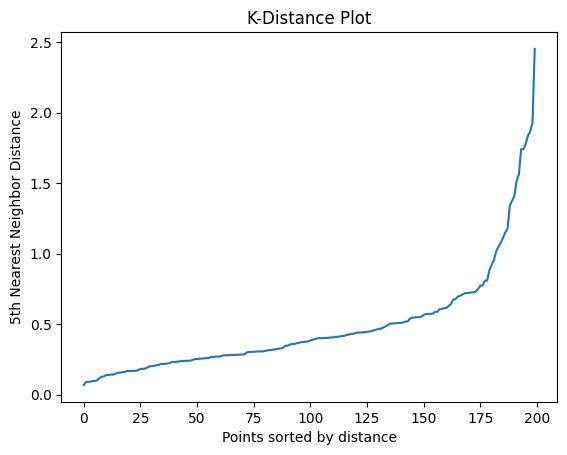

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

# Create more realistic data
X, _ = make_blobs(
    n_samples=200,
    centers=3,
    cluster_std=[0.5, 1.0, 1.5],
    random_state=42
)

min_samples = 4

knn = NearestNeighbors(n_neighbors=min_samples)
knn.fit(X)

distances, indices = knn.kneighbors(X)

k_distances = distances[:, min_samples - 1]
k_distances = np.sort(k_distances)

plt.plot(k_distances)

plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot")

plt.show()

In [7]:
# from sklearn.cluster import DBSCAN
# from sklearn.metrics import silhouette_score
#
# for eps in np.arange(0.2, 1.1, 0.1):
#
#     labels = DBSCAN(
#         eps=eps,
#         min_samples=5
#     ).fit_predict(X_scaled)
#
#     # Ignore cases where DBSCAN creates only one cluster
#     # or everything becomes noise
#     n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
#
#     if n_clusters >= 2:
#         score = silhouette_score(X_scaled, labels)
#         print(eps, score)

Let's go line by line.

### 1. Try different `eps` values

```python
for eps in np.arange(0.2, 1.1, 0.1):
```

`np.arange(0.2, 1.1, 0.1)` generates approximately:

```text
0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0
```

So the loop runs DBSCAN **9 times**, once for each `eps`.

---

### 2. Run DBSCAN

```python
labels = DBSCAN(
    eps=eps,
    min_samples=5
).fit_predict(X_scaled)
```

For example, when:

```text
eps = 0.2
```

it runs:

```python
DBSCAN(eps=0.2, min_samples=5)
```

Then when:

```text
eps = 0.3
```

it runs:

```python
DBSCAN(eps=0.3, min_samples=5)
```

and so on.

So we're asking:

> **What happens to my clustering when I change `eps`?**

---

### 3. Count the number of clusters

```python
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
```

Suppose DBSCAN produces:

```text
labels = [0, 0, 0, 1, 1, 1, -1, -1]
```

Here:

```text
0 → Cluster 0
1 → Cluster 1
-1 → Noise
```

`set(labels)` gives:

```text
{0, 1, -1}
```

So:

```python
len(set(labels))
```

is:

$$3$$

But `-1` is **noise, not a cluster**.

Therefore we subtract 1:

$$3-1=2$$

So:

```python
n_clusters = 2
```

---

### 4. Why do we check `n_clusters >= 2`?

```python
if n_clusters >= 2:
```

Silhouette Score needs at least **2 actual clusters**.

For example, if DBSCAN gives:

```text
[0, 0, 0, 0, 0]
```

there is only one cluster.

You can't meaningfully calculate a clustering separation score.

Similarly, if everything is noise:

```text
[-1, -1, -1, -1, -1]
```

there are zero clusters.

So we skip those cases.

---

### 5. Calculate Silhouette Score

```python
score = silhouette_score(X_scaled, labels)
```

This calculates:

> How well separated and compact are the clusters produced by this particular `eps`?

For example:

```text
eps       clusters       silhouette
0.2          2              0.31
0.3          2              0.48
0.4          3              0.67
0.5          3              0.72
0.6          3              0.68
```

Here, `eps = 0.5` gives the highest Silhouette Score among these tested values.

---

### 6. Print the result

```python
print(eps, score)
```

You might see:

```text
0.2 0.31
0.3 0.48
0.4 0.67
0.5 0.72
0.6 0.68
```

This lets you compare different `eps` values.

---

## So the whole code means

```text
Try eps = 0.2
      ↓
Run DBSCAN
      ↓
How many clusters?
      ↓
If ≥ 2 clusters
      ↓
Calculate Silhouette Score
      ↓
Print it

Then repeat for eps = 0.3
Then 0.4
Then 0.5
...
```

The purpose is **not to calculate `eps` mathematically**.

It is a **grid search over possible `eps` values** to find values that produce good clustering.

And ideally, you use the **k-distance plot to get a reasonable range first**, then use this kind of testing to refine it.


## Topic 6 — Scikit-learn Implementation

Now let's implement DBSCAN using `sklearn`.

### 1. Import

```python
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
```

---

### 2. Dataset

We'll use the same type of data:

```python
X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [3, 2],

    [8, 8],
    [8, 9],
    [9, 8],
    [9, 9],

    [15, 15]
])
```

---

### 3. Scale the Data

Since DBSCAN is distance-based:

```python
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

Now the features are on a comparable scale.

---

### 4. Create DBSCAN

```python
model = DBSCAN(
    eps=0.5,
    min_samples=4
)
```

Here:

```text
eps = 0.5
```

means points within distance $0.5$ are considered neighbors.

And:

```text
min_samples = 4
```

means a point needs at least 4 samples in its `eps` neighborhood to be Core.

---

### 5. Fit and Get Labels

```python
labels = model.fit_predict(X_scaled)

print(labels)
```

You might get something like:

```text
[0 0 0 0 0 1 1 1 1 -1]
```

The labels mean:

```text
0  → Cluster 0
1  → Cluster 1
-1 → Noise
```

Notice that DBSCAN doesn't necessarily give labels:

```text
1, 2, 3
```

It can use:

```text
0, 1, 2, ...
```

and `-1` specifically represents noise.

---

# 6. Visualize

```python
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")

plt.show()
```

The `c=labels` means:

> Give points different colors according to their DBSCAN cluster label.

So points with label `0` get one color, points with label `1` another, and noise `-1` another.

---

# 7. Get Number of Clusters

Remember that `-1` is noise and shouldn't be counted as a cluster.

```python
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", n_clusters)
```

For:

```text
labels = [0,0,0,0,0,1,1,1,1,-1]
```

we have:

```text
{0, 1, -1}
```

There are 3 unique labels, but `-1` is noise.

Therefore:

$$3-1=2$$

So:

```text
Number of clusters = 2
```

---

# 8. Count Noise Points

```python
n_noise = np.sum(labels == -1)

print("Number of noise points:", n_noise)
```

For:

```text
[0 0 0 0 0 1 1 1 1 -1]
```

there is one `-1`.

Therefore:

```text
Noise points = 1
```

---

# 9. Complete Code

```python
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Data
X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [3, 2],

    [8, 8],
    [8, 9],
    [9, 8],
    [9, 9],

    [15, 15]
])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
model = DBSCAN(
    eps=0.5,
    min_samples=4
)

# Clustering
labels = model.fit_predict(X_scaled)

print("Labels:", labels)

# Number of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise points
n_noise = np.sum(labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

# Visualization
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")

plt.show()
```

---

# 10. Access Core Samples

Scikit-learn also lets you find which points are **Core points**.

```python
core_indices = model.core_sample_indices_

print(core_indices)
```

For example:

```text
[0 1 2 3 5 6 7 8]
```

These are the **indices of the Core points**.

You can get the actual points:

```python
core_points = X[model.core_sample_indices_]

print(core_points)
```

This is useful because DBSCAN internally identifies the Core points first and then expands clusters from them.

---

# 11. Access Core, Border and Noise

You can combine the model information with the labels.

Noise:

```python
noise_points = X[labels == -1]
```

Core:

```python
core_points = X[model.core_sample_indices_]
```

Border points are points that:

* are not Core
* have a cluster label other than `-1`

Conceptually:

```python
border_mask = (labels != -1)

core_mask = np.zeros(len(X), dtype=bool)
core_mask[model.core_sample_indices_] = True

border_points = X[border_mask & ~core_mask]
```

So:

```text
Core
→ core_mask

Border
→ cluster point but not Core

Noise
→ label == -1
```

---

## The important Scikit-learn parameters

```python
DBSCAN(
    eps=0.5,
    min_samples=4,
    metric="euclidean"
)
```

* `eps` → neighborhood radius
* `min_samples` → minimum samples for Core
* `metric` → distance measure

The default metric is Euclidean distance.

---

### Notebook progress

```text
03_DBSCAN.ipynb

✓ 1. Introduction to Density-Based Clustering
✓ 2. Core, Border & Noise Points
✓ 3. DBSCAN Algorithm
✓ 4. eps & min_samples
✓ 5. Parameter Selection (k-distance plot)
✓ 6. Scikit-learn Implementation
→ 7. Evaluation, Comparison & Limitations
```


Yes. If you want **all the parameters and methods available in the current `sklearn.cluster.DBSCAN` API**, here they are. I'm using the current scikit-learn documentation. ([Scikit-learn][1])

# DBSCAN — All Parameters

The constructor is:

```python
DBSCAN(
    eps=0.5,
    min_samples=5,
    metric='euclidean',
    metric_params=None,
    algorithm='auto',
    leaf_size=30,
    p=None,
    n_jobs=None
)
```

### 1. `eps`

Maximum distance for two samples to be considered neighbors.

```python
eps=0.5
```

**Most important DBSCAN parameter.**

---

### 2. `min_samples`

Minimum number of samples in an `eps` neighborhood for a point to be Core.

```python
min_samples=5
```

The point itself is included in this count. ([Scikit-learn][1])

---

### 3. `metric`

Distance metric used between points.

```python
metric='euclidean'
```

Examples include:

```python
metric='euclidean'
metric='manhattan'
metric='minkowski'
```

You can also use `'precomputed'` when supplying a distance matrix. ([Scikit-learn][1])

---

### 4. `metric_params`

Additional parameters for the selected distance metric.

```python
metric_params=None
```

Usually you don't need this for basic DBSCAN.

---

### 5. `algorithm`

Algorithm used internally to find nearest neighbors.

Possible values:

```text
'auto'
'ball_tree'
'kd_tree'
'brute'
```

Default:

```python
algorithm='auto'
```

Usually leave this as `auto`. ([Scikit-learn][1])

---

### 6. `leaf_size`

Controls the leaf size used by tree-based neighbor searches.

```python
leaf_size=30
```

Mainly affects computational speed and memory, not the conceptual DBSCAN clustering rule. ([Scikit-learn][1])

---

### 7. `p`

Power parameter for the Minkowski distance.

```python
p=None
```

With the default Euclidean behavior, $p=2$ corresponds to Euclidean distance.

For example:

```text
p = 1 → Manhattan distance
p = 2 → Euclidean distance
```

([Scikit-learn][1])

---

### 8. `n_jobs`

Number of parallel jobs used for neighbor searching.

```python
n_jobs=None
```

`-1` means use all available processors.

This is mainly a performance parameter. ([Scikit-learn][1])

---

# All Methods

Current `DBSCAN` exposes these methods:

### Main methods you should know

```python
fit(X)
```

Fits DBSCAN to the data.

```python
fit_predict(X)
```

Fits DBSCAN and directly returns cluster labels.

```python
get_params()
```

Returns the model's parameters.

```python
set_params()
```

Changes the model's parameters.

### Additional API methods

```python
get_metadata_routing()
```

Used for scikit-learn's metadata-routing system.

```python
set_fit_request()
```

Controls metadata routing for `fit()`, particularly `sample_weight`.

These are advanced API functionality and aren't normally needed for basic DBSCAN. ([Scikit-learn][1])

---

# All Important Attributes

After fitting:

```python
model = DBSCAN(...)
model.fit(X)
```

you can access:

### `labels_`

Cluster label for every sample.

```python
model.labels_
```

Noise is represented by:

$$-1$$

([Scikit-learn][1])

---

### `core_sample_indices_`

Indices of the Core points.

```python
model.core_sample_indices_
```

([Scikit-learn][1])

---

### `components_`

Actual feature vectors of the Core points.

```python
model.components_
```

([Scikit-learn][1])

---

### `n_features_in_`

Number of features seen during fitting.

```python
model.n_features_in_
```

---

### `feature_names_in_`

Feature names if the input contains feature names, such as a pandas DataFrame with string column names.

```python
model.feature_names_in_
```

([Scikit-learn][1])

---

# For Your Notebook

I would **list all of them**, but only explain the important ones deeply:

```text
Parameters
├── eps ⭐⭐⭐
├── min_samples ⭐⭐⭐
├── metric ⭐⭐
├── metric_params
├── algorithm
├── leaf_size
├── p
└── n_jobs

Methods
├── fit() ⭐⭐⭐
├── fit_predict() ⭐⭐⭐
├── get_params()
├── set_params()
├── get_metadata_routing()
└── set_fit_request()

Attributes
├── labels_ ⭐⭐⭐
├── core_sample_indices_ ⭐⭐⭐
├── components_ ⭐⭐
├── n_features_in_
└── feature_names_in_
```

For your **actual learning**, `eps`, `min_samples`, `fit()`, `fit_predict()`, `labels_`, and `core_sample_indices_` are the important ones. The others are mainly API/advanced options. ([Scikit-learn][1])

[1]: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html?utm_source=chatgpt.com "DBSCAN — scikit-learn 1.9.0 documentation"
